# Drive mounting & folder structure

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

DRIVE_BASE     = '/content/drive/MyDrive/DriveSafe'
CHECKPOINT_DIR = f'{DRIVE_BASE}/checkpoints'
MODEL_DIR      = f'{DRIVE_BASE}/models'
LOG_DIR        = f'{DRIVE_BASE}/logs'

for folder in [CHECKPOINT_DIR, MODEL_DIR, LOG_DIR]:
    os.makedirs(folder, exist_ok=True)

print(" Drive mounted. Folder structure ready.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Drive mounted. Folder structure ready.


**Version check**

In [ ]:
!pip install -q tensorflow kaggle

import tensorflow as tf
print(f"TensorFlow: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Downloading 1.8GB of dataset directly using kaggle api

In [ ]:
from google.colab import files

print("Upload your kaggle.json file now:")
files.upload()

# Move it to the right place
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download MRL Eye Dataset (~1.5 GB)
!kaggle datasets download -d kutaykutlu/drowsiness-detection -p /content/mrl_dataset --unzip

print("Dataset downloaded")
!ls /content/mrl_dataset

Upload your kaggle.json file now:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/kutaykutlu/drowsiness-detection
License(s): unknown
100% 180M/180M [00:01<00:00, 98.9MB/s]

Dataset downloaded
closed_eye  open_eye


# Dataset insights

In [ ]:
import pathlib

DATASET_ROOT = '/content/mrl_dataset'

classes = sorted([
    d.name for d in pathlib.Path(DATASET_ROOT).iterdir()
    if d.is_dir()
])
print(f"Classes found: {classes}")

# Count images per class
total = 0
for c in classes:
    count = len(list(pathlib.Path(f'{DATASET_ROOT}/{c}').rglob('*.*')))
    total += count
    print(f"  {c}: {count} images")

print(f"\nTotal images: {total}")

Classes found: ['closed_eye', 'open_eye']
  closed_eye: 24000 images
  open_eye: 24000 images

Total images: 48000


# Data Pipeline

In [ ]:
import tensorflow as tf

DATASET_ROOT = '/content/mrl_dataset'
IMG_SIZE     = (64, 64)
BATCH_SIZE   = 64
EPOCHS       = 30
AUTOTUNE     = tf.data.AUTOTUNE

# Augmentation BEFORE normalization
augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
], name="augmentation")  # ← removed RandomBrightness, it was blowing up pixel values

def preprocess_train(images, labels):
    images = tf.cast(images, tf.float32) / 255.0  # normalize first
    images = augment(images, training=True)         # augment after
    return images, labels

def preprocess_eval(images, labels):
    images = tf.cast(images, tf.float32) / 255.0
    return images, labels

# Reload dataset fresh
full_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_ROOT,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    seed=42,
    shuffle=True,
)

print(f"Class names: {full_ds.class_names}  →  0={full_ds.class_names[0]}, 1={full_ds.class_names[1]}")

total_batches = tf.data.experimental.cardinality(full_ds).numpy()
train_size    = int(0.8 * total_batches)
val_size      = int(0.1 * total_batches)

train_ds = full_ds.take(train_size).map(preprocess_train, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds   = full_ds.skip(train_size).take(val_size).map(preprocess_eval, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds  = full_ds.skip(train_size + val_size).map(preprocess_eval, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

print(f"Train: {train_size} batches | Val: {val_size} batches")
print("Pipeline fixed")

Found 48000 files belonging to 2 classes.
Class names: ['closed_eye', 'open_eye']  →  0=closed_eye, 1=open_eye
Train: 600 batches | Val: 75 batches
Pipeline fixed


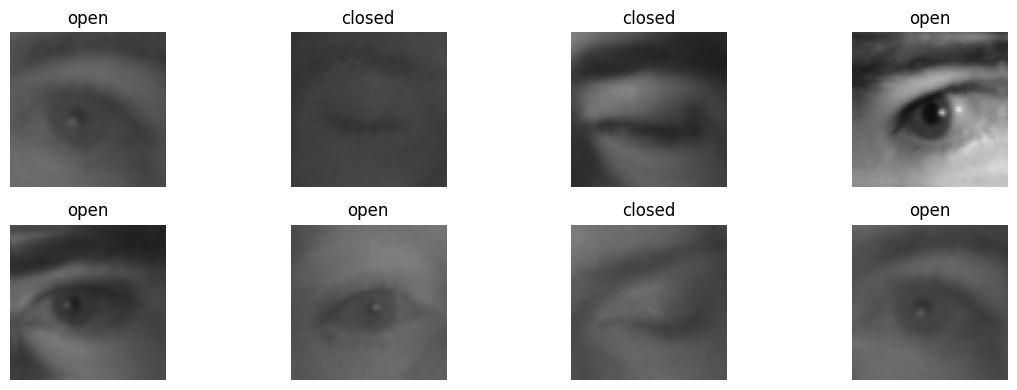

Pixel range: 0.193 → 0.434


In [ ]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
    plt.figure(figsize=(12, 4))
    for i in range(8):
        plt.subplot(2, 4, i+1)
        plt.imshow(images[i].numpy())
        plt.title(f"{'open' if labels[i] == 1 else 'closed'}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    print(f"Pixel range: {images[0].numpy().min():.3f} → {images[0].numpy().max():.3f}")
    break

# Building the CNN Model

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_drivesafe_cnn(input_shape=(64, 64, 3)):
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      input_shape=input_shape, name='conv1'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        # Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same', name='conv2'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        # Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same', name='conv3'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        # Block 4
        layers.Conv2D(128, (3,3), activation='relu', padding='same', name='conv4'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),

        # Head
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(1, activation='sigmoid', name='output'),
    ], name='DriveSafe_EyeCNN')

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')],
    )
    return model

model = build_drivesafe_cnn()
model.summary()

Model: "DriveSafe_EyeCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 258,881 (1011.25 KB)

 Trainable params: 258,177 (1008.50 KB)

 Non-trainable params: 704 (2.75 KB)

 Setup callbacks

In [ ]:
from tensorflow.keras import callbacks
import datetime

DRIVE_BASE     = '/content/drive/MyDrive/DriveSafe'
CHECKPOINT_DIR = f'{DRIVE_BASE}/checkpoints'
MODEL_DIR      = f'{DRIVE_BASE}/models'
LOG_DIR        = f'{DRIVE_BASE}/logs'

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M")

cb_list = [
    #Save best model to Drive after every epoch
    callbacks.ModelCheckpoint(
        filepath=f'{CHECKPOINT_DIR}/drivesafe_best.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1,
    ),

    #Early stopping
    callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=6,
        restore_best_weights=True,
        verbose=1,
    ),

    #Reduce LR when stuck
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    ),

    #CSV log
    callbacks.CSVLogger(
        f'{LOG_DIR}/training_log_{timestamp}.csv',
        append=True,
    ),
]

print("Callbacks ready")

Callbacks ready


Training

In [ ]:
import os

CHECKPOINT_PATH = f'{CHECKPOINT_DIR}/drivesafe_best.keras'

if os.path.exists(CHECKPOINT_PATH):
    print(f"Resuming from: {CHECKPOINT_PATH}")
    model = tf.keras.models.load_model(CHECKPOINT_PATH)
    import glob, pandas as pd
    logs = glob.glob(f'{LOG_DIR}/training_log_*.csv')
    if logs:
        df   = pd.read_csv(sorted(logs)[-1])
        done = len(df)
        print(f"   Completed {done} epochs. Resuming from epoch {done+1}...")
    else:
        done = 0
else:
    print("Fresh training — DriveSafe CNN starting...")
    done = 0

history = model.fit(
    train_ds,
    epochs=30,
    initial_epoch=done,
    validation_data=val_ds,
    callbacks=cb_list,
)

Resuming from: /content/drive/MyDrive/DriveSafe/checkpoints/drivesafe_best.keras
   Completed 8 epochs. Resuming from epoch 9...
Epoch 9/30
596/600 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8420 - auc: 0.9164 - loss: 0.3118
Epoch 9: val_accuracy improved from None to 0.56833, saving model to /content/drive/MyDrive/DriveSafe/checkpoints/drivesafe_best.keras

Epoch 9: finished saving model to /content/drive/MyDrive/DriveSafe/checkpoints/drivesafe_best.keras
600/600 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - accuracy: 0.9292 - auc: 0.9842 - loss: 0.1631 - val_accuracy: 0.5683 - val_auc: 0.5977 - val_loss: 3.4225 - learning_rate: 0.0010
Epoch 10/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9824 - auc: 0.9980 - loss: 0.0512
Epoch 10: val_accuracy improved from 0.56833 to 0.98458, saving model to /content/drive/MyDrive/DriveSafe/checkpoints/drivesafe_best.keras

Epoch 10: finished saving model to /content/drive/MyDrive/DriveSafe/checkpoints/drivesafe_best.keras
600/600 ━━━━━━━━

What happened epoch by epoch:

Epochs 1-8 → garbage (old broken pipeline, random guessing ~50%)

Epoch 9 → fixed pipeline kicks in, jumps to 84% train accuracy

Epoch 10 → 98.4% val accuracy — model clicked

Epoch 18 → 99.4% — LR reduction paying off

Epoch 25 → 99.6% — best model saved

Epoch 30 → training complete, best weights restored from Epoch 25

In [ ]:
best_model = tf.keras.models.load_model(f'{CHECKPOINT_DIR}/drivesafe_best.keras')
loss, accuracy, auc = best_model.evaluate(test_ds, verbose=1)
print(f"\n{'─'*40}")
print(f"  Test Accuracy : {accuracy*100:.2f}%")
print(f"  Test AUC      : {auc:.4f}")
print(f"  Test Loss     : {loss:.4f}")
print(f"{'─'*40}")

75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9971 - auc: 0.9999 - loss: 0.0103

────────────────────────────────────────
  Test Accuracy : 99.71%
  Test AUC      : 0.9999
  Test Loss     : 0.0103
────────────────────────────────────────


In [ ]:
import os

def export_tflite(model, variant):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)

    if variant == 'float16':
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.target_spec.supported_types = [tf.float16]

    tflite_model = converter.convert()
    path = f'{MODEL_DIR}/drivesafe_{variant}.tflite'

    with open(path, 'wb') as f:
        f.write(tflite_model)

    size_kb = os.path.getsize(path) / 1024
    print(f" {variant:12s} → {size_kb:.1f} KB  →  {path}")
    return path

print("Exporting TFLite models to Drive...\n")
export_tflite(best_model, 'float32')
export_tflite(best_model, 'float16')

# Save full keras model too
best_model.save(f'{MODEL_DIR}/drivesafe_final.keras')
print(f"\n Full Keras model saved")
print(f"\n All exports saved to Drive/DriveSafe/models/")

Exporting TFLite models to Drive...

Saved artifact at '/tmp/tmpevbfxie0'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name='input_layer_2')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  137602868475088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137602868471824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137602868472976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137602868474896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137602868475664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137602868473744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137602868475472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137602868461648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137602868474512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137602868476048: TensorSpec(shape=(), dtype=tf.r

Phase 2 summary:

Dataset: 48,000 eye images (balanced)

Model: Custom CNN, 258k parameters

Test Accuracy: 99.71%

Test AUC: 0.9999

Export: TFLite float16 — 513 KB